<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T3/semana-01/blob/main/Exemplos_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 02 - Exemplos de Machine Learning clássico

## IMPORTAÇÃO BIBLIOTECAS

In [ ]:
# CÉLULA 1: Importando Ferramentas
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
import tensorflow as tf
from __future__ import absolute_import, division, print_function, unicode_literals
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Ferramentas carregadas! Vamos ver a IA funcionando na prática.")

Ferramentas/Bibliotecas carregadas


## APRENDIZADO SUPERVISIONADO (A máquina aprende com o Gabarito)


In [ ]:
# CÉLULA 2: APRENDIZADO SUPERVISIONADO (A máquina aprende com o Gabarito)
print("--- 1. APRENDIZADO SUPERVISIONADO ---")
print("Cenário: Ensinando a IA a prever se uma máquina da fábrica vai QUEBRAR.")

# Nossos dados históricos (Temperatura do motor) e o Gabarito (0 = OK, 1 = Quebrou)
# Temperaturas: 60, 65, 70 (Normais) | 95, 100, 105 (Superaquecidas)
temperaturas = [[60], [65], [70], [95], [100], [105]]
gabarito = [0, 0, 0, 1, 1, 1]

# Criando a IA e treinando (Estudando para a prova)
modelo_supervisionado = DecisionTreeClassifier()
modelo_supervisionado.fit(temperaturas, gabarito)
print("IA Treinada com sucesso!\n")

# O Teste (A Prova): A máquina está a 90 graus. Vai quebrar?
temperatura_nova = [[82.50001]]
previsao = modelo_supervisionado.predict(temperatura_nova)

if previsao[0] == 1:
    print("maquina quebra")
else:
    print("maquina nao quebra")

Modelo treinado
[1]
maquina quebrada


## APRENDIZADO NÃO SUPERVISIONADO (A máquina encontra padrões sozinha)


Cenário: O Boticário quer criar 3 perfis de clientes, mas não sabe como separá-los.


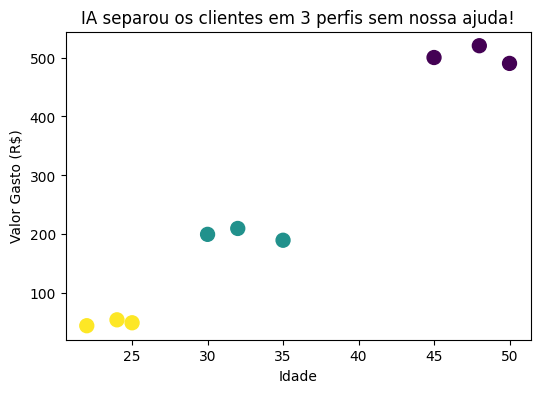

Percebam: A IA agrupou por cores quem tem comportamento parecido!


In [ ]:
# CÉLULA 3: APRENDIZADO NÃO SUPERVISIONADO (A máquina encontra padrões sozinha)
print("\n--- 2. APRENDIZADO NÃO SUPERVISIONADO ---")
print("Cenário: O Boticário quer criar 3 perfis de clientes, mas não sabe como separá-los.")

# Dados misturados: (Idade do cliente, Valor gasto na loja)
# A IA não tem o gabarito. Ela vai ter que olhar os números e formar os grupos.
dados_clientes = np.array([
    [25, 50], [22, 45], [24, 55], # Jovens que gastam pouco
    [45, 500], [48, 520], [50, 490], # Mais velhos que gastam muito
    [30, 200], [32, 210], [35, 190]  # Adultos com gasto médio
])

# Pedindo para a IA criar 3 grupos (clusters) sozinha
modelo_nao_supervisionado = KMeans(n_clusters=3, random_state=42)
grupos_criados = modelo_nao_supervisionado.fit_predict(dados_clientes)

# Mostrando o resultado visualmente
plt.figure(figsize=(6, 4))
plt.scatter(dados_clientes[:, 0], dados_clientes[:, 1], c=grupos_criados, cmap='viridis', s=100)
plt.title("IA separou os clientes em 3 perfis sem nossa ajuda!")
plt.xlabel("Idade")
plt.ylabel("Valor Gasto (R$)")
plt.show()
print("Percebam: A IA agrupou por cores quem tem comportamento parecido!")

## APRENDIZADO POR REFORÇO (Tentativa, Erro e Recompensa)


In [ ]:
# CÉLULA 4: APRENDIZADO POR REFORÇO (Tentativa, Erro e Recompensa)
print("\n--- 3. APRENDIZADO POR REFORÇO ---")
print("Cenário: Ensinando um robô a andar no labirinto.")

acoes_do_robo = ["Foi pra Esquerda", "Foi pra Direita", "Andou pra Frente"]

for tentativa in range(1, 6):
    acao = np.random.choice(acoes_do_robo)
    if acao == "Andou pra Frente":
        print(f"Tentativa {tentativa}: Robô {acao} -> ✅ RECOMPENSA! (+10 pontos). IA aprendeu que isso é bom.")
    else:
        print(f"Tentativa {tentativa}: Robô {acao} -> ❌ Bateu na parede! (-5 pontos). IA não fará mais isso.")

Cenario: ensinando um robo a andar no labirinto
Tentativa 1: Robo Andou pra frente -> RECOMPENSA! (+10 pontos). IA Aprendeu que isso é bom!
Tentativa 2: Robo Foi para a direita -> Bateu na parede! (- 5 pontos). IA não fará mais isso!
Tentativa 3: Robo Foi para a direita -> Bateu na parede! (- 5 pontos). IA não fará mais isso!
Tentativa 4: Robo Andou pra frente -> RECOMPENSA! (+10 pontos). IA Aprendeu que isso é bom!
Tentativa 5: Robo Foi para a direita -> Bateu na parede! (- 5 pontos). IA não fará mais isso!


# Aula 03 - Exemplos de Machine Learning (Deep Learning/IA)

## APRENDIZADO PROFUNDO (DEEP LEARNING)


In [ ]:
# CÉLULA 5: APRENDIZADO PROFUNDO (DEEP LEARNING)

print("\n--- 4. APRENDIZADO PROFUNDO (DEEP LEARNING) ---")
print("Teste rápido e LEVE de aprendizado profundo.")

print("Lendo dataset 'mnist' (com mais de 70 mil imagens de um conjunto de dados de dígitos escritos à mão de 0 a 9) da base do tensorflow.")
mnist = tf.keras.datasets.mnist # 'baixando' o dataset da api do tensorflow

print("Convertendo valores em pontos flutuantes (float)")
(x_train, y_train), (x_test, y_test) = mnist.load_data() # separando um X e y de treino e teste
x_train, x_test = x_train / 255.0, x_test / 255.0 # normalizando a escala dos dados entre 0 e 1 (píxeis originais variam de 0 (preto) a 255 (branco))

print("Criando o modelo de IA empilhando camadas e usando uma função otimizadora e outra de perda para o treinamento")
model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)), # achatando o 'shape' do dataset
        tf.keras.layers.Dense(128, activation='relu'), # 128 = Número de neuronios artificiais definidos manualmente que se conectam a cada um dos valores da base (28*28=784)| relu = introdução a não-linearidade (zerando valores negativos) do modelo assim permitindo aprender padrões complexos.
        tf.keras.layers.Dropout(0.2), # percentual de 'neuronios' desligado a cada loop de treinamento evitando overfitting
        tf.keras.layers.Dense(10, activation='softmax') # base contendo número de 0 a 9 = 10 numeros, logo precisamos de 10 neuronios e o softmax
])

model.compile(optimizer='adam', # otimizador de pesos e vieses para aprimoramento dos resultados
              loss='sparse_categorical_crossentropy', # função de perda que penaliza o modelo quando ele erra, fazendo assim ele aprender com seus erros e aumentar os seus acertos.
              metrics=['accuracy']) # métrica padrão de analisa acuracia (o quanto ele acertou do total)

print("Treinando e avaliando o modelo com os dados de treinamento")
model.fit(x_train, y_train, epochs=5) # variveis de treino e definição de 5 loops de treino.
model.evaluate(x_test, y_test, verbose=2) # testando com dados novos e validando a acertividade total do modelo.